# <center>Lecture 11: Constrained choice, rationing and waiting lines</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

© 2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

This notebook is the **computational companion to chapter 7, sections 7.1–7.4** of

> A. Galichon, *Discrete Choice Models: Mathematical Methods, Econometrics, and Data Science*, Princeton University Press, 2026,

covering the basics of constrained choice (7.1), constrained welfare and entropy (7.2), comparative statics (7.3), and a dynamic model of waiting lines (7.4). It runs the book's code listings `7-01`, `7-02` and `7-03`. Sections 7.5–7.7, which take the same machinery to two-sided matching, belong to the matching series. Slide deck: folders `ch7/ch7.1`–`ch7/ch7.4`.

### Learning objectives

* Rationing as a **complementarity problem**: a shadow price $\tau_y\ge0$ for each scarce option, zero unless the capacity binds.
* The reformulation as a single system of equations $\mathbf{q}(\theta)=0$, and why the fact that $\mathbf{q}$ is an **M-function** delivers existence, uniqueness, *and* an algorithm — the proof of the existence theorem is a program.
* The **logit in closed form**: $\tilde{\pi}_y=\min(e^{U_y-u},\bar\pi_y)$ with $u$ the root of a scalar equation.
* The **constrained welfare function** $\tilde{G}(U,\bar\pi)$, whose two gradients are the constrained market shares and the shadow prices.
* Simulated heterogeneity as a **linear program with capacity constraints** — the transport problem of lecture 6 with a ceiling on each column.
* **Monotone comparative statics**: tightening a capacity raises *every* shadow price. Why this is a statement about substitutability, and what it looks like when it fails.
* Waiting time as a shadow price, and a market that clears without money.

### References

* Galichon (2026). *Discrete Choice Models*. Princeton University Press. **Chapter 7, sections 7.1–7.4**.
* Ortega and Rheinboldt (1970). *Iterative Solution of Nonlinear Equations in Several Variables*. Academic Press. M-functions, Z-maps, and the coordinate-wise iteration of section 1.
* Topkis (1998). *Supermodularity and Complementarity*. Princeton University Press. The comparative statics of section 5.
* Barzel (1974). "A Theory of Rationing by Waiting". *Journal of Law and Economics* 17(1), 73–95.
* Naor (1969). "The Regulation of Queue Size by Levying Tolls". *Econometrica* 37(1), 15–24.
* Azevedo and Leshno (2016). "A Supply and Demand Framework for Two-Sided Matching Markets". *Journal of Political Economy* 124(5), 1235–1268. Shadow prices as admission cutoffs.
* Leshno (2022). "Dynamic Matching in Overloaded Waiting Lists". *American Economic Review* 112(12), 3876–3910. The waiting lines of section 6, taken seriously as a dynamic mechanism.
* Previous lectures: `dc01_random-utility-welfare-and-inversion` ($G$ and $G^\ast$, of which $\tilde{G}$ is a constrained version); `dc06_characteristics-based-demand` (the same linear program without the capacity ceiling); `dc09_dynamic-discrete-choice-finite-horizon` (where $\tau$ priced a capacity in *time*, and where the subgradient trap of section 5 first appeared); `dc04_identification-regularization-and-minimax-regret` (the $\sigma\to0$ limit of section 4).

## Motivation: a price that is not a price

Lecture 9 put a capacity constraint on a maintenance workshop and found a multiplier $\tau_t$ that priced a slot. Nothing in that construction required money to change hands: the multiplier was an accounting device that made the allocation consistent. This chapter takes that seriously as a description of markets where money genuinely does *not* clear the market — organ transplants, public school seats, day care, a walk-in clinic, a concert queue.

The mechanism is straightforward. Patients pick a hospital $y\in[Y]$, or no care ($y=0$), maximizing $U_y+\varepsilon_y$; this generates demand $\mathbf{\pi}_y(U)$. Hospital $y$ can serve at most $\bar\pi_y$. If demand exceeds capacity, something must give, and what gives is the quality of the experience: waiting, congestion, deterioration. Model that as a **utility penalty $\tau_y\ge0$** so that the effective systematic utility is $U_y-\tau_y$. Then $\tau$ must solve
$$\tau_y\ge0,\qquad \bar\pi_y-\mathbf{\pi}_y(U-\tau)\ge0,\qquad \tau_y\big(\bar\pi_y-\mathbf{\pi}_y(U-\tau)\big)=0,$$
a **complementarity problem**: a hospital that is not full is not congested.

**Why this is not just an equilibrium condition.** Three things make it computable and interesting, and they organize the lecture.

1. Write $\theta=\tau-\rho$ where $\rho$ is the unused capacity, so that $\tau=\theta^+$ and $\rho=\theta^-$. The complementarity conditions collapse into a *single* system of equations $\mathbf{\pi}(U-\theta^+)+\theta^-=\bar\pi$. The map behind it is an **M-function**, and the proof that it has a unique root is a convergent algorithm.
2. $\tau$ is a multiplier on $\pi\le\bar\pi$ in the welfare problem $\max_{\pi\le\bar\pi}\{\pi^\top U-G^\ast(\pi)\}$. Lecture 1's conjugate pair returns with a ceiling on it, and the resulting $\tilde{G}(U,\bar\pi)$ has *two* gradients that matter.
3. Tightening one capacity raises **every** shadow price. That is a theorem about substitutability, and section 5 breaks it on purpose to show what it is made of.

A hospital that has spare capacity today can be full tomorrow because a *different* hospital was rationed. Section 2 exhibits exactly that.

In [1]:
import numpy as np
from scipy import optimize, sparse as sp
from scipy.optimize import linprog
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)         # lecture number
FAST_MODE = True

np.set_printoptions(precision=4, suppress=True)

## 1. Rationing as a complementarity problem

Fix the primitives. Four hospitals and an outside option, systematic utilities $U$, capacities $\bar\pi$ expressed as fractions of the patient population. Utility is measured in units such that one point of utility is one week of waiting, so $\tau_y$ can be read directly as a waiting time.

In [2]:
Y = 4
U = np.array([1.4, 1.0, 0.6, -0.4])
pibar = np.array([0.10, 0.12, 0.30, 0.40])
labels = [f'H{y + 1}' for y in range(Y)]


def pi_logit(V):
    '''Logit market shares with an outside option normalized to zero.'''
    e = np.exp(V)
    return e / (1 + e.sum())


pi_free = pi_logit(U)
print(f"{'':<12}" + ''.join(f'{l:>10}' for l in labels))
print(f"{'U':<12}" + ''.join(f'{v:>10.2f}' for v in U))
print(f"{'capacity':<12}" + ''.join(f'{v:>10.2f}' for v in pibar))
print(f"{'demand':<12}" + ''.join(f'{v:>10.4f}' for v in pi_free))
print(f"{'excess':<12}" + ''.join(f'{v:>10.4f}' for v in pi_free - pibar))
print(f'\nunconstrained demand for the outside option: {1 - pi_free.sum():.4f}')
print(f'hospitals over capacity before any rationing: '
      f'{[labels[y] for y in range(Y) if pi_free[y] > pibar[y]]}')

                    H1        H2        H3        H4
U                 1.40      1.00      0.60     -0.40
capacity          0.10      0.12      0.30      0.40
demand          0.3950    0.2648    0.1775    0.0653
excess          0.2950    0.1448   -0.1225   -0.3347

unconstrained demand for the outside option: 0.0974
hospitals over capacity before any rationing: ['H1', 'H2']


### The $\theta$ reformulation, and the proof as an algorithm

Let $\rho_y=\bar\pi_y-\mathbf{\pi}_y(U-\tau)$ be the unused capacity. Complementarity says $\tau_y\ge0$, $\rho_y\ge0$ and $\tau_y\rho_y=0$, which is exactly the statement that a *single* real number $\theta_y$ carries both: $\tau_y=\theta_y^+$ and $\rho_y=\theta_y^-$. Proposition 7.2 then replaces the three families of conditions with
$$\mathbf{q}(\theta):=\bar\pi-\theta^--\mathbf{\pi}(U-\theta^+)=0.$$

Proposition 7.3 shows $\mathbf{q}$ is an **M-function** — off-diagonal antitone, and strongly non-reversing — which gives uniqueness at once. The existence proof is more useful than that: it starts at $\theta^0=c\mathbf{1}_Y$ with $c$ large, and solves $\mathbf{q}_y(\theta_y,\theta_{-y})=0$ one coordinate at a time, producing a sequence that is **decreasing in every coordinate** and bounded below. That is a Gauss–Seidel sweep, and it is worth running rather than reading.

In [3]:
def q_of(theta, Uv=U, pb=pibar):
    return pb - np.maximum(-theta, 0) - pi_logit(Uv - np.maximum(theta, 0))


def solve_theta(Uv=U, pb=pibar, tol=1e-13, maxit=200, trace=False):
    '''The existence proof of proposition 7.4, run as an algorithm.'''
    theta = np.full(len(pb), np.abs(Uv).max() + 10.0)      # theta^0 = c 1_Y
    hist = [theta.copy()]
    for s in range(maxit):
        for y in range(len(pb)):
            f = lambda t: q_of(np.r_[theta[:y], t, theta[y + 1:]], Uv, pb)[y]
            theta[y] = optimize.brentq(f, -pb[y], theta[y], xtol=1e-15, rtol=8.9e-16)
        hist.append(theta.copy())
        if np.abs(hist[-1] - hist[-2]).max() < tol:
            break
    return (theta, np.array(hist)) if trace else theta


theta, hist = solve_theta(trace=True)
tau, rho = np.maximum(theta, 0), np.maximum(-theta, 0)
print(f'{len(hist) - 1} sweeps to 1e-13\n')
print(f"{'':<12}" + ''.join(f'{l:>10}' for l in labels))
print(f"{'theta':<12}" + ''.join(f'{v:>10.4f}' for v in theta))
print(f"{'tau (weeks)':<12}" + ''.join(f'{v:>10.4f}' for v in tau))
print(f"{'rho (spare)':<12}" + ''.join(f'{v:>10.4f}' for v in rho))

print(f'\nis the sequence decreasing in every coordinate? '
      f'{bool((np.diff(hist, axis=0) <= 1e-12).all())}')
print(f'residual |q(theta)|_inf                  : {np.abs(q_of(theta)).max():.2e}')
print(f'complementarity max_y tau_y * rho_y      : {(tau * rho).max():.2e}')
assert np.abs(q_of(theta)).max() < 1e-12
assert (tau * rho).max() < 1e-12

19 sweeps to 1e-13

                    H1        H2        H3        H4
theta           2.4556    1.8733    0.5570   -0.2074
tau (weeks)     2.4556    1.8733    0.5570    0.0000
rho (spare)     0.0000    0.0000    0.0000    0.2074

is the sequence decreasing in every coordinate? True
residual |q(theta)|_inf                  : 1.26e-15
complementarity max_y tau_y * rho_y      : 0.00e+00


Nineteen sweeps, monotone in every coordinate, and the answer satisfies complementarity to machine precision.

The result is worth reading before we go further. Three of the four hospitals are congested, with waits of $2.46$, $1.87$ and $0.56$ weeks, and only the fourth has spare capacity — $0.207$ of the population's worth. But look back at the first table: **H3 was not over capacity to begin with.** Its unconstrained demand was $0.178$ against a capacity of $0.30$. It becomes congested only because H1 and H2 are rationed and their patients go somewhere. Rationing one option creates scarcity at another, and that is the whole content of the comparative statics of section 5.

## 2. The logit in closed form

For the logit the complementarity system can be solved by hand. Writing $u$ for the value of the problem, so that $\pi_0=e^{-u}$, the continued example of the chapter gives
$$\tau_y=\max\big(U_y-u-\log\bar\pi_y,\,0\big),\qquad \tilde{\pi}_y=\min\big(e^{U_y-u},\,\bar\pi_y\big),$$
where the single scalar $u$ is fixed by requiring the shares to sum to one:
$$e^{-u}+\sum_{y\in[Y]}\min\big(e^{U_y-u},\bar\pi_y\big)=1.$$
Listing `7-01` solves this with Brent's method, in the variable $\mu=e^{-u}$.

In [4]:
def constrained_logit(Uv=U, pb=pibar):
    '''Listing 7-01: solve the scalar equation for mu = exp(-u).'''
    mu = optimize.brentq(lambda m: m + np.minimum(m * np.exp(Uv), pb).sum() - 1,
                         1e-14, 1, xtol=1e-16, rtol=8.9e-16)
    u = -np.log(mu)
    return np.maximum(Uv - u - np.log(pb), 0.0), np.minimum(np.exp(Uv - u), pb), u


tau_cf, pi_cf, u_cf = constrained_logit()
print(f'u = {u_cf:.10f}   (unconstrained value would be '
      f'{np.log(1 + np.exp(U).sum()):.10f})')
print(f'tau (closed form) = {tau_cf}')
print(f'tau (section 1)   = {tau}')
print(f'max difference    = {np.abs(tau_cf - tau).max():.2e}')
print(f'\nconstrained shares {pi_cf}, outside {1 - pi_cf.sum():.4f}, '
      f'total {pi_cf.sum() + np.exp(-u_cf):.10f}')
assert np.abs(tau_cf - tau).max() < 1e-9

u = 1.2469844275   (unconstrained value would be 2.3288297339)
tau (closed form) = [2.4556 1.8733 0.557  0.    ]
tau (section 1)   = [2.4556 1.8733 0.557  0.    ]
max difference    = 1.73e-14

constrained shares [0.1    0.12   0.3    0.1926], outside 0.2874, total 1.0000000000


### The example in the appendix does not bind

Listing `7-01` is run on $U=(0.2,-0.3,0.5)$ with $\bar\pi=(0.3,0.5,0.6)$. It prints a number, and the number is correct — but it is worth checking what it is.

In [5]:
U_l = np.array([0.2, -0.3, 0.5])
pibar_l = np.array([0.3, 0.5, 0.6])
tau_l, pi_l, u_l = constrained_logit(U_l, pibar_l)
print(f'listing 7-01 prints u = {u_l:.10f}')
print(f'unconstrained value log(1 + sum exp U) = '
      f'{np.log(1 + np.exp(U_l).sum()):.10f}')
print(f'\nunconstrained shares {pi_logit(U_l)}')
print(f'capacities            {pibar_l}')
print(f'shadow prices         {tau_l}   <- all zero')
print(f'total capacity {pibar_l.sum():.1f} for a population of 1')

listing 7-01 prints u = 1.5284322286
unconstrained value log(1 + sum exp U) = 1.5284322286

unconstrained shares [0.2649 0.1607 0.3576]
capacities            [0.3 0.5 0.6]
shadow prices         [0. 0. 0.]   <- all zero
total capacity 1.4 for a population of 1


No constraint binds: the capacities sum to $1.4$ for a unit population, every one of them exceeds the corresponding unconstrained share, and $\tau=0$. The listing's $u$ is the ordinary unconstrained log-sum-exp to ten decimals. The code is right and the example exercises none of it — anyone reading the appendix to see what rationing does will see nothing. The capacities of section 1 were chosen to bind.

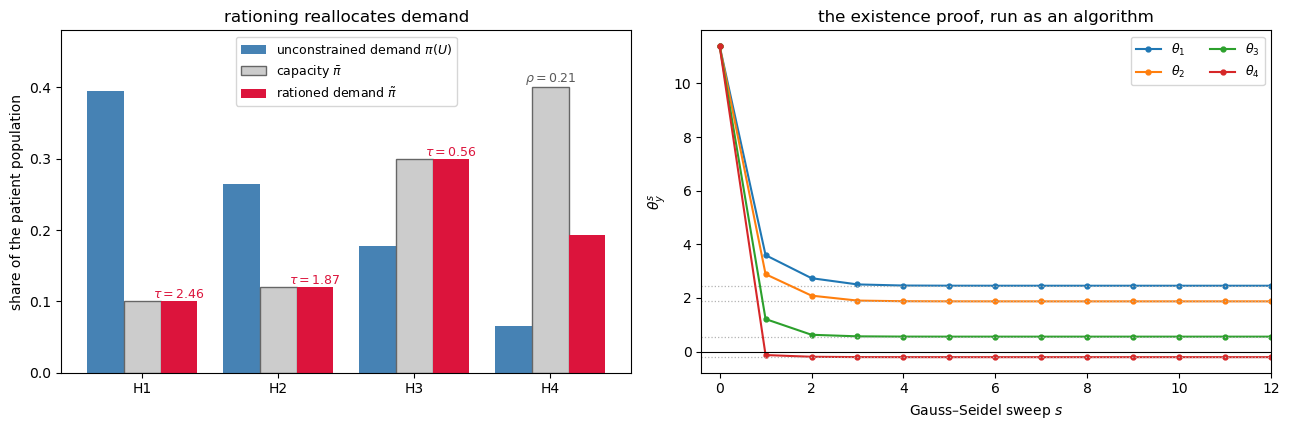

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

a, w = ax[0], 0.27
xs = np.arange(Y)
a.bar(xs - w, pi_free, w, color='steelblue', label='unconstrained demand $\\pi(U)$')
a.bar(xs, pibar, w, color='0.8', edgecolor='0.4', label='capacity $\\bar\\pi$')
a.bar(xs + w, pi_cf, w, color='crimson', label='rationed demand $\\tilde\\pi$')
for y in range(Y):
    if tau_cf[y] > 0:
        a.annotate(f'$\\tau={tau_cf[y]:.2f}$', (y + w, pi_cf[y]), ha='center',
                   va='bottom', fontsize=9, color='crimson')
    else:
        a.annotate(f'$\\rho={pibar[y] - pi_cf[y]:.2f}$', (y, pibar[y]), ha='center',
                   va='bottom', fontsize=9, color='0.35')
a.set_xticks(xs)
a.set_xticklabels(labels)
a.set_ylabel('share of the patient population')
a.set_ylim(0, 0.48)
a.legend(fontsize=9)
a.set_title('rationing reallocates demand')

b = ax[1]
for y in range(Y):
    b.plot(np.arange(len(hist)), hist[:, y], 'o-', ms=3.5, label=f'$\\theta_{{{y + 1}}}$')
    b.axhline(theta[y], color='0.7', ls=':', lw=0.9)
b.axhline(0, color='k', lw=0.8)
b.set_xlabel('Gauss–Seidel sweep $s$')
b.set_ylabel('$\\theta^s_y$')
b.set_xlim(-0.4, 12)
b.legend(fontsize=9, ncol=2)
b.set_title('the existence proof, run as an algorithm')

plt.tight_layout()
plt.show()

*Left.* What rationing does. Blue is what patients would choose if capacity were unlimited; grey is capacity; red is what they actually get. H1 and H2 are cut back hard — H1 from $0.395$ to $0.10$ — and the displaced patients do not go to the outside option, they go to **H3, which fills to its capacity of $0.30$ despite having been under-demanded**. H4 is the only hospital with spare capacity, $0.207$ of the population. The waits are $2.46$, $1.87$ and $0.56$ weeks.

*Right.* The coordinate-wise iteration from the proof of proposition 7.4. All four coordinates start at $c=11.4$ and descend monotonically to their fixed values, the first three to positive limits (shadow prices) and the fourth through zero to $-0.207$ (spare capacity). The monotonicity is not incidental: it is the M-function property, and it is what makes the proof work. Note also that the first sweep does almost all the work — the initial $c$ is deliberately crude.

## 3. Constrained welfare

Lecture 1 wrote the welfare function as a conjugate,
$$G(U)=\max_{\pi\ge0}\Big\{\sum_y\pi_yU_y-G^\ast(\pi)\Big\},$$
with the market shares as the argmax. Impose the ceiling and the same construction gives the **constrained welfare function**
$$\tilde{G}(U,\bar\pi)=\max_{\pi\le\bar\pi}\Big\{\sum_y\pi_yU_y-G^\ast(\pi)\Big\}=\min_{\tau\ge0}\Big\{\sum_y\bar\pi_y\tau_y+G(U-\tau)\Big\},$$
the two lines being primal and dual of one another. Theorem 7.5 then says that the two gradients of $\tilde{G}$ are the two objects of section 1:
$$\nabla_U\tilde{G}(U,\bar\pi)=\tilde{\mathbf{\pi}}(U,\bar\pi),\qquad \nabla_{\bar\pi}\tilde{G}(U,\bar\pi)=\mathbf{\tau}(U,\bar\pi).$$
Two programs, one number, and two derivatives that are the answer to the whole problem. We check all four claims.

In [7]:
def G(V):
    return np.log(1 + np.exp(V).sum())


def Gstar(p):                                   # entropy of choice, logit
    p0 = 1 - p.sum()
    return (p * np.log(p)).sum() + p0 * np.log(p0)


def Gtilde_dual(Uv=U, pb=pibar):
    r = optimize.minimize(lambda t: pb @ t + G(Uv - t), np.zeros(len(pb)),
                          jac=lambda t: pb - pi_logit(Uv - t),
                          bounds=[(0, None)] * len(pb), method='L-BFGS-B',
                          options={'ftol': 1e-16, 'gtol': 1e-14})
    return r.fun, r.x


def Gtilde_primal(Uv=U, pb=pibar):
    r = optimize.minimize(lambda p: -(p @ Uv - Gstar(p)), 0.5 * pb,
                          bounds=[(1e-12, b) for b in pb],
                          constraints=[{'type': 'ineq',
                                        'fun': lambda p: 1 - 1e-9 - p.sum()}],
                          method='SLSQP', options={'ftol': 1e-16, 'maxiter': 500})
    return -r.fun, r.x


v_d, t_d = Gtilde_dual()
v_p, p_p = Gtilde_primal()
print(f'G~ from the dual   = {v_d:.12f}   tau = {t_d}')
print(f'G~ from the primal = {v_p:.12f}   pi  = {p_p}')
print(f'duality gap = {abs(v_d - v_p):.2e}')
print(f'|tau - section 1| = {np.abs(t_d - tau).max():.2e}, '
      f'|pi - section 2| = {np.abs(p_p - pi_cf).max():.2e}')

h, E = 1e-6, np.eye(Y)
gU = np.array([(Gtilde_dual(U + h * E[y])[0] - Gtilde_dual(U - h * E[y])[0]) / (2 * h)
               for y in range(Y)])
gP = np.array([(Gtilde_dual(pb=pibar + h * E[y])[0]
                - Gtilde_dual(pb=pibar - h * E[y])[0]) / (2 * h) for y in range(Y)])
print(f'\ngrad_U    G~ = {gU}   vs pi_tilde, error {np.abs(gU - pi_cf).max():.2e}')
print(f'grad_pibar G~ = {gP}   vs tau,      error {np.abs(gP - tau).max():.2e}')
assert abs(v_d - v_p) < 1e-9 and np.abs(gU - pi_cf).max() < 1e-6

G~ from the dual   = 1.884434500132   tau = [2.4556 1.8733 0.557  0.    ]
G~ from the primal = 1.884434500132   pi  = [0.1    0.12   0.3    0.1926]
duality gap = 5.77e-15
|tau - section 1| = 4.15e-10, |pi - section 2| = 6.33e-09

grad_U    G~ = [0.1    0.12   0.3    0.1926]   vs pi_tilde, error 6.41e-11
grad_pibar G~ = [2.4556 1.8733 0.557  0.    ]   vs tau,      error 7.12e-11


Both gradients land on the right objects to ten decimals, and the two programs agree to $6\times10^{-15}$. The second one is the economically interesting one: $\partial\tilde{G}/\partial\bar\pi_y$ is the welfare value of one more unit of capacity at hospital $y$, and it equals the waiting time there. **A congested hospital's waiting time measures exactly what a marginal bed is worth**, in the same units.

One caution, carried over from lecture 9: $\tilde{G}$ is concave in $\bar\pi$ but need not be differentiable, and at a kink $\tau$ is a subgradient rather than a derivative. Here the logit smooths everything and the finite differences agree; with no heterogeneity, as in section 4, they will not.

## 4. Simulated heterogeneity, and three ways to be heterogeneous

Nothing so far required the logit. Replace $\varepsilon$ by an i.i.d.\ sample $\varepsilon_{iy}$ over $i\in[I]$ and the entropy of choice becomes a transport problem, so that $\tilde{G}$ becomes a **linear program with a ceiling on each column**:
$$\tilde{G}_I(U,\bar\pi)=\max_{\lambda\ge0}\sum_{iy}\lambda_{iy}(U_y+\varepsilon_{iy})\quad\text{s.t.}\quad\sum_{y\in[0:Y]}\lambda_{iy}=\tfrac1I\ \ [u_i],\qquad\sum_i\lambda_{iy}\le\bar\pi_y\ \ [\tau_y\ge0],$$
whose dual is $\min_{u,\tau\ge0}\{\frac1I\sum_iu_i+\sum_y\bar\pi_y\tau_y\}$ subject to $u_i\ge U_y-\tau_y+\varepsilon_{iy}$. This is lecture 6's semi-discrete transport problem with an upper bound added to the destination marginals, and the shadow prices are the dual variables on those bounds. Listing `7-02` writes it for Gurobi; we use HiGHS through `scipy.optimize.linprog`, with sparse constraint matrices.

We draw $\varepsilon$ from a **centred** Gumbel, $\varepsilon-\gamma$, so that the simulated value converges to the book's $G$ rather than to $G+\gamma$; subtracting a constant from every $\varepsilon_{iy}$ shifts each $u_i$ and leaves $\tau$ untouched.

In [8]:
def simulated_choice(eps, Uv=U, pb=pibar):
    '''Listing 7-02 on HiGHS. Returns (tau, u_i, shares, value, lambda).'''
    I, Yp = eps.shape
    c = -(np.concatenate([[0.0], Uv])[None, :] + eps).ravel()
    A_eq = sp.kron(sp.eye(I), np.ones((1, Yp)), format='csr')
    cols = sp.hstack([sp.csr_matrix((Yp - 1, 1)), sp.eye(Yp - 1)], format='csr')
    A_ub = sp.kron(np.ones((1, I)), cols, format='csr')
    r = linprog(c, A_ub=A_ub, b_ub=pb, A_eq=A_eq, b_eq=np.full(I, 1.0 / I),
                bounds=(0, None), method='highs')
    lam = r.x.reshape(I, Yp)
    return (-r.ineqlin.marginals, -r.eqlin.marginals, lam.sum(axis=0)[1:], -r.fun, lam)


eps = rng.gumbel(size=(2000, Y + 1)) - np.euler_gamma
tau_s, u_i, share_s, val_s, lam = simulated_choice(eps)

print(f'{"":<28}{"simulated (I=2000)":>20}{"analytic":>12}')
print(f'{"value G~":<28}{val_s:>20.4f}{v_d:>12.4f}')
print(f'{"mean u_i, = G(U - tau)":<28}{u_i.mean():>20.4f}{G(U - tau):>12.4f}')
for y in range(Y):
    print(f'{"tau, " + labels[y]:<28}{tau_s[y]:>20.4f}{tau[y]:>12.4f}')
print(f'\nshares {share_s} against capacities {pibar}')
print(f'agents assigned to exactly one option: '
      f'{((lam > 1e-12).sum(axis=1) == 1).mean():.1%}')
print(f'\nthe dual objective splits as G~ = mean(u_i) + pibar.tau:')
print(f'   mean individual welfare  {u_i.mean():.4f}')
print(f'   scarcity rent pibar.tau  {pibar @ tau_s:.4f}  '
      f'({pibar @ tau_s / val_s:.1%} of the total)')
print(f'   analytic rent            {pibar @ tau:.4f}')

                              simulated (I=2000)    analytic
value G~                                  1.8802      1.8844
mean u_i, = G(U - tau)                    1.2542      1.2470
tau, H1                                   2.4329      2.4556
tau, H2                                   1.7937      1.8733
tau, H3                                   0.5581      0.5570
tau, H4                                   0.0000      0.0000

shares [0.1   0.12  0.3   0.193] against capacities [0.1  0.12 0.3  0.4 ]
agents assigned to exactly one option: 100.0%

the dual objective splits as G~ = mean(u_i) + pibar.tau:
   mean individual welfare  1.2542
   scarcity rent pibar.tau  0.6260  (33.3% of the total)
   analytic rent            0.6375


The linear program hands back an **assignment**: every one of the 2,000 agents receives exactly one option, at mass $1/I$, even though nothing in the formulation required integrality. That is the same phenomenon as in lecture 6 — the constraint matrix is totally unimodular — and it is what makes the dual variables interpretable as individual utilities $u_i$ and per-option prices $\tau_y$.

The dual objective decomposes as $\tilde{G}=\frac1I\sum_iu_i+\bar\pi^\top\tau$: average individual welfare *plus* the value of the capacity. The second term is $0.638$ of a total $1.884$, so **a third of the measured welfare of this system is the scarcity rent on hospital beds** — which nobody collects.

In [9]:
grid = [125, 250, 500, 1000, 2000] if FAST_MODE else [125, 250, 500, 1000, 2000, 4000]
reps = 10 if FAST_MODE else 20
rmse = []
for I in grid:
    e = np.array([np.abs(simulated_choice(rng.gumbel(size=(I, Y + 1))
                                          - np.euler_gamma)[0] - tau).max()
                  for _ in range(reps)])
    rmse.append(np.sqrt((e ** 2).mean()))
    print(f'I = {I:>5}:  RMSE(tau) = {rmse[-1]:.4f}')
slope = np.polyfit(np.log(grid), np.log(rmse), 1)[0]
print(f'\nfitted slope of log RMSE on log I: {slope:.3f}  '
      f'(parametric rate would be -0.5)')

I =   125:  RMSE(tau) = 0.4482


I =   250:  RMSE(tau) = 0.2313


I =   500:  RMSE(tau) = 0.1869


I =  1000:  RMSE(tau) = 0.1601


I =  2000:  RMSE(tau) = 0.0937

fitted slope of log RMSE on log I: -0.505  (parametric rate would be -0.5)


The simulated shadow prices converge to the analytic ones at the parametric rate. That is worth noting because $\tau$ is defined by a *complementarity* condition, and the set of binding constraints has to be identified correctly before the prices mean anything; a rate of $I^{-1/2}$ says the finite sample gets the active set right and pays only the ordinary sampling cost.

### Three heterogeneity structures

Listing `7-03` organizes the material as a small class hierarchy: a parent `ChoiceProblem` and three children — no heterogeneity, logit heterogeneity, simulated heterogeneity. We reproduce it, replacing the Gurobi model in the third child with the HiGHS program above. The no-heterogeneity child is a **greedy fill**: sort options by payoff and pour the population into them until each is full, stopping at the outside option.

In [10]:
class ChoiceProblem:
    def __init__(self, n_x, alpha_x_y):
        self.n_x, self.alpha_x_y = n_x, alpha_x_y
        self.X, self.Y = alpha_x_y.shape


class IndividualChoiceProblem(ChoiceProblem):
    '''No heterogeneity: greedy fill in order of payoff.'''
    def choice(self, constraint=None):
        mubar = (self.n_x[:, None] * np.ones((self.X, self.Y))
                 if constraint is None else constraint)
        a = np.block([[self.alpha_x_y, np.zeros((self.X, 1))]])
        mu = np.zeros((self.X, self.Y + 1))
        for x in range(self.X):
            res = self.n_x[x]
            for yi in np.argsort(a[x, :])[::-1]:
                if yi == self.Y:
                    mu[x, yi] = res
                    break
                if mubar[x, yi] > 0:
                    mu[x, yi] = min(res, mubar[x, yi])
                    res -= mu[x, yi]
                if res == 0:
                    break
        return mu[:, :-1]


class LogitChoiceProblem(ChoiceProblem):
    '''Logit heterogeneity: the scalar equation of listing 7-01, per type.'''
    def choice(self, constraint=None):
        mubar = (self.n_x[:, None] * np.ones((self.X, self.Y))
                 if constraint is None else constraint)
        mu = np.zeros((self.X, self.Y))
        for x in range(self.X):
            m0 = optimize.brentq(
                lambda m: m + np.minimum(m * np.exp(self.alpha_x_y[x]),
                                         mubar[x]).sum() - self.n_x[x],
                0, self.n_x[x])
            mu[x] = np.minimum(m0 * np.exp(self.alpha_x_y[x]), mubar[x])
        return mu


class SimulatedChoiceProblem(ChoiceProblem):
    '''Simulated heterogeneity: listing 7-02's linear program, on HiGHS.'''
    def __init__(self, n_x, alpha_x_y, eps_i_y):
        super().__init__(n_x, alpha_x_y)
        self.eps = eps_i_y

    def choice(self, constraint=None):
        mubar = (self.n_x[:, None] * np.ones((self.X, self.Y))
                 if constraint is None else constraint)
        out = np.zeros((self.X, self.Y))
        for x in range(self.X):
            out[x] = self.n_x[x] * simulated_choice(
                self.eps, self.alpha_x_y[x], mubar[x] / self.n_x[x])[2]
        return out


n_x, alpha, mubar = np.array([1.0]), U[None, :], pibar[None, :]
print('no heterogeneity :', IndividualChoiceProblem(n_x, alpha).choice(mubar)[0])
print('logit            :', LogitChoiceProblem(n_x, alpha).choice(mubar)[0])
print('simulated        :',
      SimulatedChoiceProblem(n_x, alpha, eps).choice(mubar)[0])

no heterogeneity : [0.1  0.12 0.3  0.  ]
logit            : [0.1    0.12   0.3    0.1926]


simulated        : [0.1   0.12  0.3   0.193]


Three structures, three answers, and the second and third agree because the simulated shocks *are* Gumbel. The first is different in a specific way: with no heterogeneity every patient ranks the hospitals identically, so the greedy fill exhausts H1, then H2, then H3, and sends nobody to H4 — whose payoff $-0.4$ is below the outside option. The logit sends $0.193$ of the population there anyway, because some patients draw a large $\varepsilon_4$.

### The $\sigma\to0$ limit

Scale the heterogeneity by $\sigma$ — equivalently, replace $U$ by $U/\sigma$ — and the logit solution should approach the greedy one. This is the fourth appearance of that limit in the series: lecture 4 took logistic regression to a minimax-regret linear program, lecture 6 took entropic transport to a Laguerre diagram, lecture 9 took a smoothed Bellman equation to a linear program, and here it takes rationing to a queue in which everyone agrees on the ranking.

In [11]:
sigmas = np.array([2.0, 1.0, 0.5, 0.25, 0.12, 0.06, 0.03, 0.015])
paths = np.array([LogitChoiceProblem(n_x, alpha / sg).choice(mubar)[0] for sg in sigmas])
greedy = IndividualChoiceProblem(n_x, alpha).choice(mubar)[0]
print(f"{'sigma':>8}" + ''.join(f'{l:>10}' for l in labels) + f"{'outside':>10}")
for k, sg in enumerate(sigmas):
    print(f'{sg:>8.3f}' + ''.join(f'{v:>10.4f}' for v in paths[k])
          + f'{1 - paths[k].sum():>10.4f}')
print(f"{'greedy':>8}" + ''.join(f'{v:>10.4f}' for v in greedy)
      + f'{1 - greedy.sum():>10.4f}')
print(f'\nmax deviation at sigma = {sigmas[-1]}: '
      f'{np.abs(paths[-1] - greedy).max():.2e}')

# the shadow price at sigma -> 0: a subgradient, not a derivative
print(f'\nsigma-scaled shadow prices tau (= sigma * tau of the scaled problem):')
for sg in (1.0, 0.25, 0.06, 0.015):
    print(f'  sigma = {sg:<6} tau = {sg * constrained_logit(U / sg, pibar)[0]}')
print(f'  limit as sigma -> 0            = {np.maximum(U, 0)}  '
      f'(that is U where it is rationed, 0 elsewhere)')
print('\nthe marginal option under the greedy fill is the OUTSIDE option, whose')
print('value is zero, so u -> 0 and tau_y -> U_y for every rationed hospital.')

   sigma        H1        H2        H3        H4   outside
   2.000    0.1000    0.1200    0.3000    0.2161    0.2639
   1.000    0.1000    0.1200    0.3000    0.1926    0.2874
   0.500    0.1000    0.1200    0.3000    0.1488    0.3312
   0.250    0.1000    0.1200    0.3000    0.0806    0.3994
   0.120    0.1000    0.1200    0.3000    0.0165    0.4635
   0.060    0.1000    0.1200    0.3000    0.0006    0.4794
   0.030    0.1000    0.1200    0.3000    0.0000    0.4800
   0.015    0.1000    0.1200    0.3000    0.0000    0.4800
  greedy    0.1000    0.1200    0.3000    0.0000    0.4800

max deviation at sigma = 0.015: 1.26e-12

sigma-scaled shadow prices tau (= sigma * tau of the scaled problem):
  sigma = 1.0    tau = [2.4556 1.8733 0.557  0.    ]
  sigma = 0.25   tau = [1.7462 1.3006 0.6715 0.    ]
  sigma = 0.06   tau = [1.494  1.0831 0.6281 0.    ]
  sigma = 0.015  tau = [1.4235 1.0208 0.6071 0.    ]
  limit as sigma -> 0            = [1.4 1.  0.6 0. ]  (that is U where it is rationed

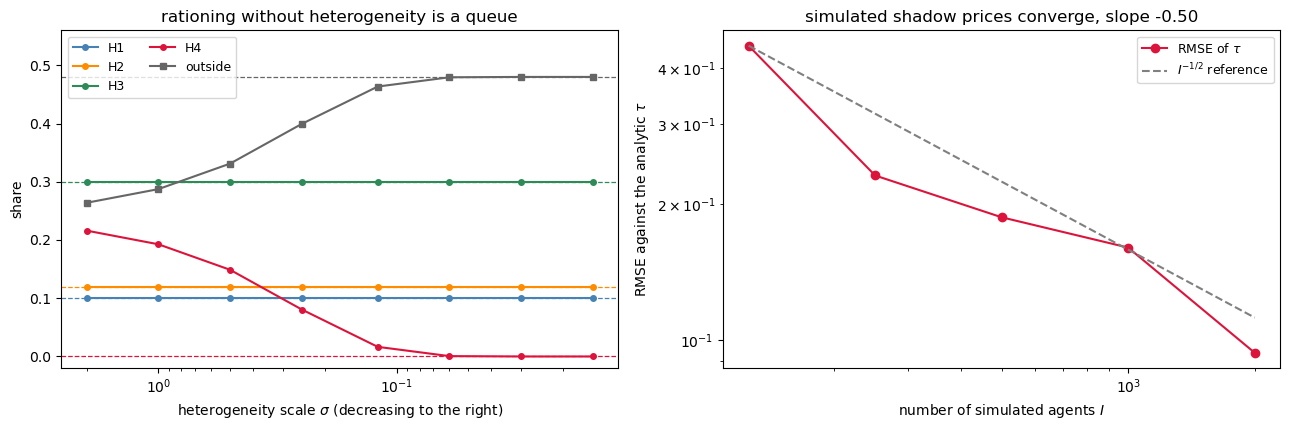

In [12]:
cols = ['steelblue', 'darkorange', 'seagreen', 'crimson']
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

a = ax[0]
for y in range(Y):
    a.plot(sigmas, paths[:, y], 'o-', ms=4, color=cols[y], label=labels[y])
    a.axhline(greedy[y], color=cols[y], ls='--', lw=0.9)
a.plot(sigmas, 1 - paths.sum(axis=1), 's-', ms=4, color='0.4', label='outside')
a.axhline(1 - greedy.sum(), color='0.4', ls='--', lw=0.9)
a.set_xscale('log')
a.invert_xaxis()
a.set_xlabel('heterogeneity scale $\\sigma$ (decreasing to the right)')
a.set_ylabel('share')
a.set_ylim(-0.02, 0.56)
a.legend(fontsize=9, ncol=2)
a.set_title('rationing without heterogeneity is a queue')

b = ax[1]
b.loglog(grid, rmse, 'o-', color='crimson', label='RMSE of $\\tau$')
ref = rmse[0] * (np.array(grid) / grid[0]) ** -0.5
b.loglog(grid, ref, '--', color='0.5', label='$I^{-1/2}$ reference')
b.set_xlabel('number of simulated agents $I$')
b.set_ylabel('RMSE against the analytic $\\tau$')
b.legend(fontsize=9)
b.set_title(f'simulated shadow prices converge, slope {slope:.2f}')

plt.tight_layout()
plt.show()

*Left.* The $\sigma\to0$ limit. The three constrained hospitals sit at their capacities throughout — they are full at every level of heterogeneity — while the share going to H4 and to the outside option is entirely a matter of taste dispersion. As $\sigma$ falls the $0.193$ at H4 drains away to the outside option, and at $\sigma=0.015$ the logit and the greedy fill agree to $10^{-12}$. The picture is the same one as in lectures 4, 6 and 9: **heterogeneity is what makes an allocation problem smooth**, and removing it leaves a queue in which everyone agrees on the ranking and the marginal patient is indifferent.

The shadow prices tell the same story more sharply. As $\sigma\to0$ the scaled waits converge to $\sigma\tau\to U=(1.4,1.0,0.6)$ — the *level* of each hospital's utility, not a difference. The reason is that under the greedy fill the marginal option is the outside option, worth zero, so a patient at a rationed hospital must be made exactly indifferent to going home. Convergence is slow, though: at $\sigma=0.015$ the first component is still $1.42$ against a limit of $1.40$, because the marginal patient is pinned down only up to a $\sigma\log$ term.

*Right.* The simulated shadow prices of listing `7-02` against the analytic ones, on log axes. The fitted slope is $-0.50$, tracking the parametric reference: identifying which capacity constraints bind costs nothing asymptotically. The curve wanders around the reference line because a root-mean-square error over ten replications is itself a noisy statistic.

## 5. Comparative statics: tightening one capacity raises every price

Theorem 7.6 says the map $\bar\pi\mapsto\mathbf{\tau}(U,\bar\pi)$ is **antitone** and $\bar\pi\mapsto\mathbf{\rho}(U,\bar\pi)$ is **isotone**. The first is stronger than it looks: tightening the capacity of hospital $y$ raises not only $\tau_y$ but $\tau_{y'}$ for every other $y'$, because the displaced patients push the others toward *their* limits.

The proof is one line given proposition 7.3: $\mathbf{q}$ is an M-function, so its root moves monotonically with the right-hand side. What that line encodes is **substitutability** — a property discrete choice models have automatically, since an agent takes exactly one option.

In [13]:
print(f"{'pibar_3':>9}" + ''.join(f'{"tau " + l:>11}' for l in labels)
      + f"{'rho_4':>9}")
for b3 in (0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05):
    pb = pibar.copy()
    pb[2] = b3
    t_b, p_b, _ = constrained_logit(pb=pb)
    print(f'{b3:>9.2f}' + ''.join(f'{v:>11.4f}' for v in t_b)
          + f'{pb[3] - p_b[3]:>9.4f}')

R = 300 if FAST_MODE else 1000
bad_tau = bad_rho = 0
for _ in range(R):
    Uv = rng.normal(0, 1.2, Y)
    lo = rng.uniform(0.02, 0.5, Y)
    hi = lo + rng.uniform(0, 0.3, Y)                 # lo <= hi componentwise
    t_lo, p_lo, _ = constrained_logit(Uv, lo)
    t_hi, p_hi, _ = constrained_logit(Uv, hi)
    bad_tau += int((t_lo < t_hi - 1e-10).any())      # antitone: tau(lo) >= tau(hi)
    bad_rho += int((lo - p_lo > hi - p_hi + 1e-10).any())
print(f'\n{R} random pairs with pibar <= pibar-prime:')
print(f'  violations of antitone tau: {bad_tau}')
print(f'  violations of isotone rho : {bad_rho}')
assert bad_tau == 0 and bad_rho == 0

  pibar_3     tau H1     tau H2     tau H3     tau H4    rho_4
     0.35     2.3456     1.7633     0.2928     0.0000   0.2274
     0.30     2.4556     1.8733     0.5570     0.0000   0.2074
     0.25     2.5547     1.9724     0.8384     0.0000   0.1873
     0.20     2.6448     2.0625     1.1517     0.0000   0.1672
     0.15     2.7275     2.1452     1.5221     0.0000   0.1472
     0.10     2.8039     2.2216     2.0039     0.0000   0.1271
     0.05     2.8749     2.2925     2.7680     0.0000   0.1070

300 random pairs with pibar <= pibar-prime:
  violations of antitone tau: 0
  violations of isotone rho : 0


Squeezing H3 from $0.35$ to $0.05$ raises its own shadow price from $0.29$ to $2.77$ — and raises H1's from $2.35$ to $2.87$ and H2's from $1.76$ to $2.29$, although neither capacity moved. The spare capacity at H4 falls at the same time, from $0.227$ to $0.107$: the rationed patients have to go somewhere, and the only place left is the hospital nobody wanted. Over three hundred random configurations there is not a single violation of either half of the theorem.

### Where it fails

The theorem is not an accounting identity; it is a consequence of substitutability, and it can be broken. The book's example is gloves: if right and left gloves are complements, making right gloves scarce does not raise the shadow price of left gloves, it *destroys* it, because nobody wants a left glove alone. No discrete choice model can express that — an agent takes one option — so we step outside and write a demand system by hand:
$$D_1(V)=s(V_1),\qquad D_2(V)=s(V_1)\,s(V_2),\qquad s(v)=\frac{1}{1+e^{-v}},$$
in which option 2 is wanted only to the extent that option 1 is available. The root of $\mathbf{q}$ is still unique here — $\mathbf{q}_1$ depends on $\theta_1$ alone, so one may solve for $\theta_1$ and then for $\theta_2$ — and five different starting points return the same root at every capacity, so the failure is not about existence.

In [14]:
def s_of(v):
    return 1.0 / (1.0 + np.exp(-v))


def demand_complements(V):
    return np.array([s_of(V[0]), s_of(V[0]) * s_of(V[1])])


def solve_complements(pb, Uv=np.array([1.0, 1.0])):
    f = lambda th: pb - np.maximum(-th, 0) - demand_complements(Uv - np.maximum(th, 0))
    roots = []
    for st in ([0., 0.], [1., 1.], [3., 3.], [-.1, -.1], [2., -.1]):
        r = optimize.fsolve(f, st, full_output=True)
        if np.abs(r[1]['fvec']).max() < 1e-11:
            roots.append(np.round(r[0], 8))
    return np.maximum(roots[0], 0), len(np.unique(np.array(roots), axis=0))


print('complements: D_1 = s(V_1), D_2 = s(V_1) s(V_2), U = (1, 1), pibar_2 = 0.45\n')
print(f"{'pibar_1':>9}{'tau_1':>10}{'tau_2':>10}{'D_1':>10}{'D_2':>10}"
      f"{'rho_2':>10}{'roots':>8}")
for b1 in (0.80, 0.70, 0.60, 0.50, 0.40, 0.30, 0.20):
    t_c, nr = solve_complements(np.array([b1, 0.45]))
    d_c = demand_complements(np.array([1.0, 1.0]) - t_c)
    print(f'{b1:>9.2f}{t_c[0]:>10.4f}{t_c[1]:>10.4f}{d_c[0]:>10.4f}{d_c[1]:>10.4f}'
          f'{0.45 - d_c[1]:>10.4f}{nr:>8}')

complements: D_1 = s(V_1), D_2 = s(V_1) s(V_2), U = (1, 1), pibar_2 = 0.45

  pibar_1     tau_1     tau_2       D_1       D_2     rho_2   roots
     0.80    0.0000    0.5293    0.7311    0.4500    0.0000       1
     0.70    0.1527    0.4122    0.7000    0.4500    0.0000       1
     0.60    0.5945    0.0000    0.6000    0.4386    0.0114       1
     0.50    1.0000    0.0000    0.5000    0.3655    0.0845       1
     0.40    1.4055    0.0000    0.4000    0.2924    0.1576       1
     0.30    1.8473    0.0000    0.3000    0.2193    0.2307       1
     0.20    2.3863    0.0000    0.2000    0.1462    0.3038       1


Tightening $\bar\pi_1$ from $0.80$ to $0.60$ raises $\tau_1$ from $0$ to $0.59$, as it must — and drives $\tau_2$ from $0.53$ **to zero**, in the wrong direction. The spare capacity at option 2 moves the wrong way too, from $0$ up to $0.011$ on that step, and on to $0.23$ by the time $\bar\pi_1$ reaches $0.30$. Both halves of theorem 7.6 fail, and the root is unique at every capacity, so nothing pathological is going on: the demand system is simply not substitutable, and $\mathbf{q}$ is not an M-function.

**The monotonicity is a property of discrete choice, not of rationing.** Any model in which an agent takes exactly one option gets it for free; any model in which options are consumed together loses it. That is a useful thing to know before extending a rationing model to bundles — school seats and transport passes, say, or a treatment and the follow-up appointment that goes with it.

## 6. Waiting lines

Section 7.4 gives the mechanism its dynamic reading. A flow $\bar\pi_y$ of slots arrives each period; patients arriving at $t$ anticipate a wait $\tau^t_y$ and choose accordingly, so demand is $\mathbf{\pi}_y(U-\tau^t)$; and the stock of available slots evolves as
$$N^{t+1}_y=N^t_y+\bar\pi_y-\mathbf{\pi}_y(U-\tau^t).$$
A stationary solution requires that where the stock is finite the market clears exactly, and where it is infinite the option is under-demanded — which is precisely the complementarity system of section 1. So the stationary wait is $\tau=\mathbf{\tau}(U,\bar\pi)$: **the queue is the price**.

We check the two halves of that statement. First: at the stationary wait, the stocks behave as the theory says.

In [15]:
d_star = pi_logit(U - tau)
N, stocks = np.zeros(Y), [np.zeros(Y)]
print(f"{'t':>5}" + ''.join(f'{"N " + l:>11}' for l in labels))
for t in range(1, 41):
    N = N + pibar - d_star
    stocks.append(N.copy())
    if t in (1, 5, 10, 20, 40):
        print(f'{t:>5}' + ''.join(f'{v:>11.4f}' for v in N))
stocks = np.array(stocks)
print(f'\nrho = pibar - pi(U - tau) = {pibar - d_star}')
print('the three rationed hospitals hold a constant stock of zero; the fourth')
print(f'accumulates {pibar[3] - d_star[3]:.4f} per period and diverges.')

    t       N H1       N H2       N H3       N H4
    1     0.0000     0.0000     0.0000     0.2074
    5     0.0000     0.0000     0.0000     1.0369
   10     0.0000     0.0000     0.0000     2.0737
   20     0.0000     0.0000     0.0000     4.1474
   40     0.0000     0.0000     0.0000     8.2948

rho = pibar - pi(U - tau) = [0.     0.     0.     0.2074]
the three rationed hospitals hold a constant stock of zero; the fourth
accumulates 0.2074 per period and diverges.


Exactly as stated: finite stock $\Rightarrow$ the market clears, infinite stock $\Rightarrow$ excess capacity. H4's unused slots pile up at $0.207$ per period forever, which in this model is what "no queue" means.

Second: does the queue *find* the price? The book characterizes the stationary solution but does not say how the system gets there. A natural adjustment is that yesterday's excess demand lengthens today's queue,
$$\tau^{t+1}=\big(\tau^t+\delta\,(\mathbf{\pi}(U-\tau^t)-\bar\pi)\big)^+,$$
which is a projected gradient step on the dual problem of section 3 — the queue does not know it is minimizing $\bar\pi^\top\tau+G(U-\tau)$, but it is.

In [16]:
def tatonnement(delta, T=400):
    t_cur, path = np.zeros(Y), []
    for t in range(T):
        path.append(t_cur.copy())
        t_cur = np.maximum(t_cur + delta * (pi_logit(U - t_cur) - pibar), 0.0)
    return np.array(path)


print(f"{'delta':>7}{'err at t=25':>14}{'err at t=100':>15}{'first t < 1e-8':>17}")
for delta in (0.5, 1.0, 2.0, 4.0):
    pth = tatonnement(delta)
    err = np.abs(pth - tau).max(axis=1)
    hit = int(np.argmax(err < 1e-8)) if (err < 1e-8).any() else -1
    print(f'{delta:>7.1f}{err[25]:>14.2e}{err[100]:>15.2e}'
          f'{hit if hit > 0 else "not reached":>17}')

tau_path = tatonnement(2.0)
err2 = np.abs(tau_path - tau).max(axis=1)
first_pos = [int(np.argmax(tau_path[:, y] > 1e-12)) if (tau_path[:, y] > 1e-12).any()
             else -1 for y in range(Y)]
print(f'\nfirst period at which each queue is positive: '
      f'{dict(zip(labels, first_pos))}  (-1 = never)')
print(f'\nat delta = 2 the error contracts by a factor '
      f'{(err2[60] / err2[20]) ** (1 / 40):.4f} per period,')
print(f'reaching {err2[100]:.1e} after 100 periods. Final tau = {tau_path[-1]}')
assert np.abs(tau_path[-1] - tau).max() < 1e-9

  delta   err at t=25   err at t=100   first t < 1e-8
    0.5      7.79e-01       5.52e-02      not reached
    1.0      3.05e-01       1.44e-03              266
    2.0      4.39e-02       6.18e-07              128


    4.0      5.26e-04       3.11e-14               59

first period at which each queue is positive: {'H1': 1, 'H2': 1, 'H3': 4, 'H4': -1}  (-1 = never)

at delta = 2 the error contracts by a factor 0.8620 per period,
reaching 6.2e-07 after 100 periods. Final tau = [2.4556 1.8733 0.557  0.    ]


The queue converges geometrically to the shadow price from any starting point, and the step size matters in the ordinary way: $\delta=0.5$ never gets there in 400 periods, $\delta=2$ reaches $10^{-8}$ in 128, $\delta=4$ in 59. A real queue has no $\delta$ to tune, which is a reason to expect the transition to be slow and the steady state to be the right object to look at.

The right panel below shows the paths. H1's queue climbs to two and a half weeks, H2's to just under two, H3's — the hospital that was not over-demanded to begin with — grows more slowly and settles at half a week, and H4 never forms a queue at all. Note *when* H3's queue appears: the cell above reports the first period at which each wait is positive, and H1 and H2 start queueing in period 1 while H3 waits until period 4. Its queue is entirely a consequence of the rationing elsewhere.

**What the market clears with.** Adding up the dual objective, $\tilde{G}=\frac1I\sum_iu_i+\bar\pi^\top\tau$, the second term was $0.638$ — a third of total welfare, dissipated in waiting rather than transferred to anyone. That is the standard indictment of rationing by queue, and it is also, in this model, an exact number rather than a slogan.

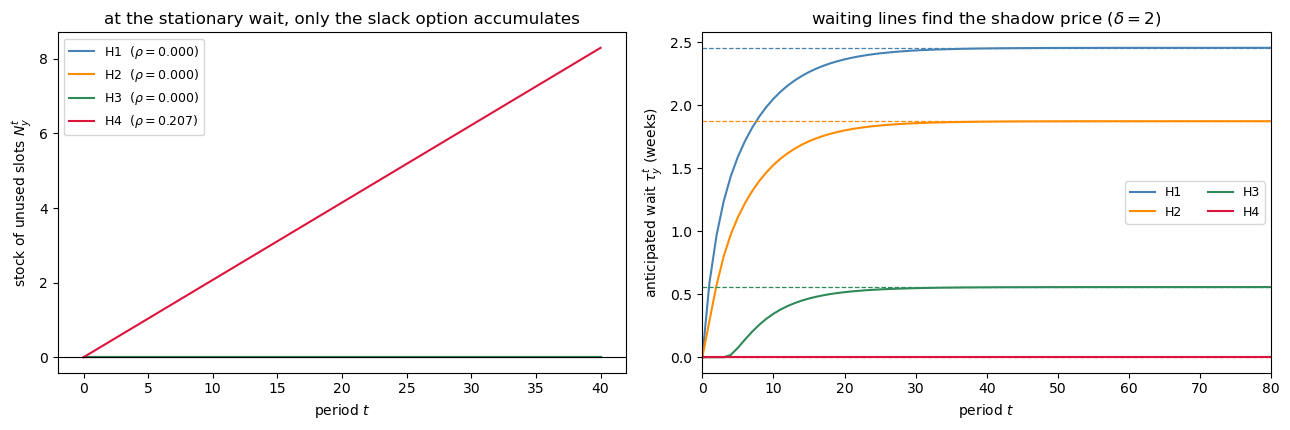

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

a = ax[0]
for y in range(Y):
    a.plot(np.arange(len(stocks)), stocks[:, y], color=cols[y],
           label=f'{labels[y]}  ($\\rho={pibar[y] - d_star[y]:.3f}$)')
a.axhline(0, color='k', lw=0.8)
a.set_xlabel('period $t$')
a.set_ylabel('stock of unused slots $N^t_y$')
a.legend(fontsize=9)
a.set_title('at the stationary wait, only the slack option accumulates')

b = ax[1]
for y in range(Y):
    b.plot(np.arange(len(tau_path)), tau_path[:, y], color=cols[y], label=labels[y])
    b.axhline(tau[y], color=cols[y], ls='--', lw=0.9)
b.set_xlabel('period $t$')
b.set_ylabel('anticipated wait $\\tau^t_y$ (weeks)')
b.set_xlim(0, 80)
b.legend(fontsize=9, ncol=2)
b.set_title('waiting lines find the shadow price ($\\delta = 2$)')

plt.tight_layout()
plt.show()

*Left.* The stock of unused slots at the stationary wait. Three of the four lines lie exactly on zero: at H1, H2 and H3 the market clears every period, and nothing accumulates. H4 accumulates $0.207$ of the population's worth of unused capacity per period and diverges, which in the language of section 7.4 is the statement $N_y=+\infty\implies\pi_y(U-\tau)\le\bar\pi_y$.

*Right.* The queue finding the price. All four waits start at zero; H1's and H2's climb immediately, since those hospitals are over-demanded from the first period. H3's stays at zero for the first two periods and only then begins to grow — it is not over-demanded on its own, and its queue exists solely because H1 and H2 have queues. H4 never forms one. The dashed lines are the shadow prices computed three different ways in sections 1, 2 and 3.

## Summing up

* Capacity constraints introduce nonnegative shadow prices. Complementarity says that an option has a positive shadow price exactly when its capacity binds.
* The excess-demand system is an M-function. Its existence and uniqueness proof therefore supplies a coordinate-wise algorithm for computing equilibrium.
* Constrained welfare remains a dual object: its derivatives with respect to utilities are choice probabilities, while its derivatives with respect to capacities are shadow prices.
* The simulated model is a transportation linear program with column capacities. Tightening one capacity can raise every shadow price because the options are substitutes.
* Waiting time can clear a market in place of money, but it dissipates rather than transfers the scarcity rent. The queue-adjustment dynamics converge to the same shadow prices computed by the static dual problem.


## Exercises

**1. (Computation — a better root finder.)** The scalar equation $e^{-u}+\sum_y\min(e^{U_y-u},\bar\pi_y)=1$ that listing `7-01` hands to Brent's method has structure: in the variable $\mu=e^{-u}$ the left-hand side is increasing, piecewise affine and concave, with kinks at $\mu=\bar\pi_ye^{-U_y}$. (i) Sort the kinks and locate the root exactly by identifying the affine piece it lies on, in $O(Y\log Y)$ and with no iteration. (ii) Verify agreement with `brentq` to machine precision. (iii) Time both at $Y=10,10^3,10^5$ and report the crossover. (iv) The same structure appears in the nested logit; state what changes.

**2. (Theory and computation — the M-function property.)** Section 1 used the coordinate-wise iteration from the proof of proposition 7.4. (i) Verify numerically that $\mathbf{q}$ is a Z-map, i.e.\ that $\partial\mathbf{q}_y/\partial\theta_{y'}\le0$ for $y'\ne y$, on a grid of $\theta$. (ii) Show that the Jacobian of $\mathbf{q}$ is an M-matrix wherever it exists, and that it fails to exist exactly on the coordinate hyperplanes $\theta_y=0$. (iii) Compare the Gauss–Seidel sweep of section 1 against a semismooth Newton method on $\mathbf{q}$, in iterations and in robustness to the starting point $c$. (iv) At $Y=200$ with random $U$ and $\bar\pi$, which wins?

**3. (Computation — simulated rationing without the logit.)** Rerun section 4's linear program with $\varepsilon$ drawn from (i) a multivariate normal with correlated components, (ii) a nested structure in which H1 and H2 share a nest. In each case report $\tau$ and compare with the logit answer at the same capacities. (iii) Does the ordering of the shadow prices ever reverse relative to the logit? (iv) Estimate how large $I$ must be for the active set — the identity of the binding constraints — to be recovered correctly in 99% of samples.

**4. (Economics — is rationing by queue worse than a price?)** Section 6 found that $\bar\pi^\top\tau=0.638$ of a total welfare of $1.884$ is dissipated in waiting. (i) Compute the allocation that would result if the same $\tau$ were charged as a monetary price and rebated lump-sum, and compare total welfare. (ii) Now suppose patients differ in their cost of waiting: patient $i$ suffers $\kappa_i\tau_y$ with $\kappa_i$ independent of $\varepsilon_i$. Show that the queue no longer allocates to the patients who value care most, and quantify the loss as a function of the dispersion of $\kappa$. (iii) Under what condition on the joint distribution of $(\kappa_i,\varepsilon_i)$ does rationing by queue *outperform* a uniform price?

**5. (Computation and economics — capacity planning.)** A regulator may add $C$ units of capacity in total, allocated across the four hospitals. (i) Show that the welfare-maximizing allocation equalizes the shadow prices $\tau_y$ across hospitals that receive capacity, and compute it for $C=0.05,0.10,0.20$. (ii) Section 3 warned that $\tilde{G}$ is concave but not always differentiable in $\bar\pi$; find a $\bar\pi$ at which the finite-difference derivative from the left and from the right disagree, and explain what the solver reports there. (iii) Repeat (i) in the $\sigma\to0$ limit of section 4 and explain why the answer becomes discontinuous in $C$.

---

### Run notes

`FAST_MODE = True` uses 10 replications and five sample sizes in the convergence study of section 4, and 300 random configurations in section 5; `False` uses 20, six and 1,000. Every assertion holds in both modes. The notebook uses numpy, scipy and matplotlib only.

Listings `7-02` and `7-03` are written for Gurobi. The linear programs here are solved with HiGHS through `scipy.optimize.linprog`, with sparse Kronecker constraint matrices, which needs no licence; the duals are read from `ineqlin.marginals` and `eqlin.marginals` with the sign flipped, since `linprog` minimizes.

Two remarks on the appendix code. Listing `7-01`'s example, $U=(0.2,-0.3,0.5)$ with $\bar\pi=(0.3,0.5,0.6)$, has **no binding constraint**: total capacity is $1.4$ for a unit population, and the $u$ it prints equals the unconstrained $\log(1+\sum_ye^{U_y})$ to ten decimals. Section 2 shows this and then uses capacities that bind. Listing `7-03`'s three classes take a capacity $\bar\mu_{xy}$ for each type–option pair and solve the types independently; section 4 runs them at $X=1$, which is the setting of sections 7.1–7.4, and the type index is then inert.

The $\varepsilon$ of section 4 is drawn as $\text{Gumbel}-\gamma$ rather than $\text{Gumbel}$. Without the centring the simulated value exceeds the book's $\tilde{G}$ by Euler's constant $0.5772$, since $\mathbb{E}[\max_y(U_y+\varepsilon_y)]=\gamma+\log\sum_ye^{U_y}$ for the standard Gumbel while the book's $G$ omits the $\gamma$. The shadow prices are unaffected, being differences.

**Next:** lecture 12 closes the series with general heterogeneities — beyond logit, beyond simulation — and returns to minimax regret.